## Setup

In [223]:
#Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set up connection to sql database
conn = sqlite3.connect("db.sqlite3")

# Make a sql query, taking specific box score stats and adding on team date from another table
query = """
SELECT 
    tg.game_id,
    tg.team_id,
    tg.is_home,
    tg.possessions,
    tg.pace,
    tg.fg_made,
    tg.fg_attempted,
    tg.two_pt_made,
    tg.two_pt_attempted,
    tg.three_pt_made,
    tg.three_pt_attempted,
    tg.three_pt_pct,
    tg.ft_made,
    tg.ft_attempted,
    tg.ft_rate,
    tg.points,
    tg.assists,
    tg.steals,
    tg.blocks,
    tg.turnovers,
    tg.reb_offensive,
    tg.reb_defensive,
    tg.reb_total,
    tg.fouls_total,
    tg.fouls_technical,
    tg.fouls_flagrant,
    tg.points_fast_break,
    tg.rating,
    tg.points_in_paint,
    tg.game_score,
    tg.largest_lead,
    tg.oreb_pct,
    g.start_date AS game_date,
    g.season
FROM opencourt_gameteamstats tg
JOIN opencourt_game g
    ON tg.game_id = g.id
"""

# Read in the data
df = pd.read_sql(query, conn)
# Sort by date and by team
df = df.dropna()
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values(['team_id', 'game_date'])
# Test for first 4 rows
df.head(4)


,game_id,team_id,is_home,possessions,pace,fg_made,fg_attempted,two_pt_made,two_pt_attempted,three_pt_made,...,fouls_technical,fouls_flagrant,points_fast_break,rating,points_in_paint,game_score,largest_lead,oreb_pct,game_date,season
319,155,1,1,68.0,68.0,25.0,57.0,18.0,36.0,7.0,...,1.0,0.0,8.0,107.4,28.0,47.7,13.0,37.5,2025-11-07 01:00:00,2026
997,493,1,0,67.0,67.0,24.0,57.0,22.0,47.0,2.0,...,0.0,0.0,9.0,98.5,40.0,46.7,8.0,25.6,2025-11-15 02:00:00,2026
1341,674,1,0,64.0,64.5,17.0,55.0,12.0,40.0,5.0,...,0.0,0.0,8.0,76.6,22.0,28.8,3.0,50.0,2025-11-19 01:00:00,2026
1921,961,1,1,63.0,62.5,20.0,58.0,11.0,36.0,9.0,...,0.0,0.0,3.0,96.8,20.0,47.8,13.0,43.2,2025-11-25 02:00:00,2026


In [224]:
GAME_DATA_LIMIT = False

# Point differential
df['point_diff'] = df['points'] - np.nan  # Placeholder for opponent points, will merge later

# Offensive efficiency (points / possessions)
df['off_eff'] = df['points'] / df['possessions'].replace(0, np.nan)

# Offensive rebounds per possession
df['orr_eff'] = df['reb_offensive'] / df['possessions'].replace(0, np.nan)

# Turnover rate
df['turnover_rate'] = df['turnovers'] / df['possessions'].replace(0, np.nan)

# Effective FG%
df['efg_pct'] = (df['fg_made'] + 0.5 * df['three_pt_made']) / df['fg_attempted'].replace(0, np.nan)

# Assist turnover ratio
df['ato_rto'] = df['assists'] / df['turnovers']

# Get the opposition points in order to calculate differential for classification
opp_df = df[['game_id', 'team_id', 'points']].rename(columns={'team_id':'opp_team_id', 'points':'opp_points'})
df = df.merge(opp_df, on='game_id')
df = df[df['team_id'] != df['opp_team_id']]  # exclude same team
df['point_diff'] = df['points'] - df['opp_points']

# Group by team
group = df.groupby(['team_id', 'season']) # Added 'season' with brackets

df['games_played'] = group.cumcount() # find the amount of games played for each team

# Rolling stats: mean of all previous games (shift=1 avoids leakage)
df['avg_ftr'] = group['ft_rate'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_turnover_rate'] = group['turnover_rate'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df['avg_efg_pct'] = group['efg_pct'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_point_diff'] = group['point_diff'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_pace'] = group['pace'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df['avg_oreb_pct'] = group['oreb_pct'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_rating'] = group['rating'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_ato_rto'] = group['ato_rto'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_largest_lead'] = group['largest_lead'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_blocks'] = group['blocks'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df = df[df['avg_efg_pct'].notna()]  # Remove first game of each team
 
df_a = df.copy()
df_b = df.copy()

matchups = df_a.merge(
    df_b,
    on='game_id',
    suffixes=('_a', '_b')
)

# Keep one row per matchup
matchups = matchups[matchups['team_id_a'] < matchups['team_id_b']]

# Feature differences
matchups['diff_turnover_rate'] = matchups['avg_turnover_rate_a'] - matchups['avg_turnover_rate_b']
matchups['diff_efg_pct'] = matchups['avg_efg_pct_a'] - matchups['avg_efg_pct_b']
matchups['diff_point_diff'] = matchups['avg_point_diff_a'] - matchups['avg_point_diff_b']
matchups['diff_pace'] = matchups['avg_pace_a'] - matchups['avg_pace_b']
matchups['diff_avg_ftr'] = matchups['avg_ftr_a'] - matchups['avg_ftr_b']
matchups['diff_avg_oreb_pct'] = matchups['avg_oreb_pct_a'] - matchups['avg_oreb_pct_b']
matchups['diff_avg_ato_rto'] = matchups['avg_ato_rto_a'] - matchups['avg_ato_rto_b']
matchups['diff_avg_blocks'] = matchups['avg_blocks_a'] - matchups['avg_blocks_b']
matchups['diff_avg_rating'] = matchups['avg_rating_a'] - matchups['avg_rating_b']
matchups['home_advantage'] = matchups['is_home_a'] - matchups['is_home_b']

matchups['team_a_win'] = (matchups['points_a'] > matchups['points_b']).astype(int)

if GAME_DATA_LIMIT:
    matchups = matchups[(matchups['games_played_a'] >= 5) & (matchups['games_played_b'] >= 5)]

features = [
    'diff_efg_pct',
    'diff_turnover_rate',
    'diff_point_diff',
    'diff_pace',
    'diff_avg_ftr',
    'diff_avg_rating',
    'diff_avg_blocks',
    'diff_avg_oreb_pct',
    'diff_avg_ato_rto',
    'home_advantage',
]

X = matchups[features]
y = matchups['team_a_win']

In [225]:
print(X.head())
print(y.head())

   diff_efg_pct  diff_turnover_rate  diff_point_diff  diff_pace  diff_avg_ftr  \
1     -0.076623            0.037758       -16.500000  -3.000000      2.350000   
3     -0.019031           -0.013112         1.500000  -1.625000     -1.100000   
5     -0.034356            0.059969         0.333333  -1.833333      0.666667   
7     -0.087784           -0.008493         0.250000 -11.500000     -9.265000   
9     -0.003189            0.026112        -2.400000   3.720000      2.480000   

   diff_avg_rating  diff_avg_blocks  diff_avg_oreb_pct  diff_avg_ato_rto  \
1       -12.950000        -3.000000           8.400000         -0.457143   
3         3.200000        -0.750000           3.125000         -0.256557   
5       -10.633333         0.666667           3.866667         -0.239502   
7        -5.515000         0.700000          13.755000         -0.461676   
9       -14.740000         0.000000           5.220000         -0.696762   

   home_advantage  
1              -1  
3              -

In [226]:
# Ensure matchup DataFrame has season column (carry it from df_a or df_b)
train_mask = matchups['game_date_a'] < '2026-02-20'

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[~train_mask].copy()
y_test = y[~train_mask].copy()


### XGBoost CLassifier Test

In [227]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

seed = np.random.randint(0, 10000)

xg_clas = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, colsample_bynode=0.8, random_state=seed)

xg_clas.fit(X_train, y_train)

preds = xg_clas.predict(X_test)
accuracy = accuracy_score(y_test, preds)
print(accuracy)


0.6855895196506551


<Axes: >

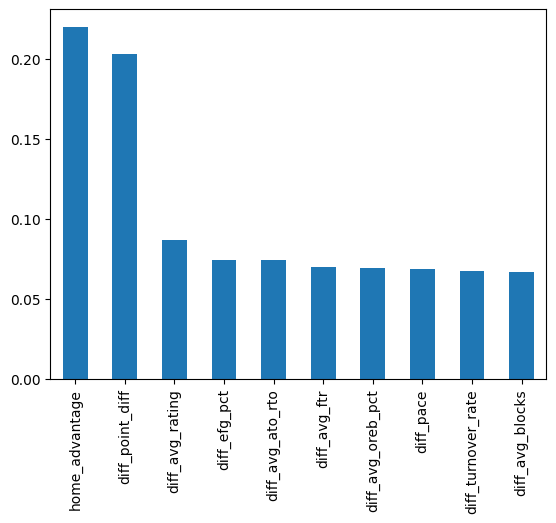

In [228]:
importances = pd.Series(xg_clas.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()

### Random Forest Classifier Test

In [229]:
from sklearn.ensemble import RandomForestClassifier

seed = np.random.randint(0, 10000)

RF_clas = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=seed)
RF_clas.fit(X_train, y_train)

y_pred = RF_clas.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


0.6855895196506551


<Axes: >

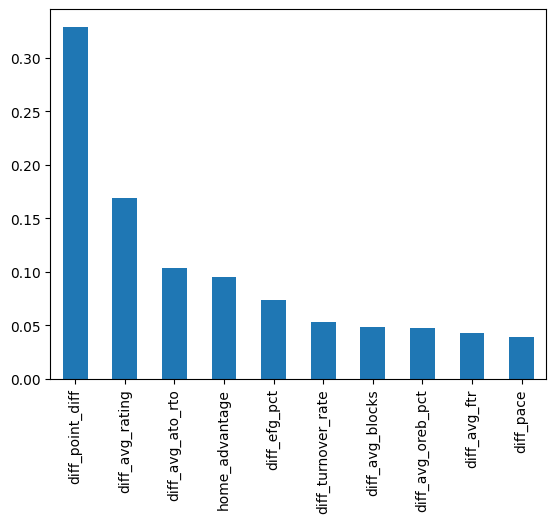

In [230]:
importances = pd.Series(RF_clas.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()